In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
print(df)  

      Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      Sample Question Papers Practiced 

In [4]:
df = pd.read_csv("Student_Performance.csv")
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [5]:
df.isnull()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
9995,False,False,False,False,False,False
9996,False,False,False,False,False,False
9997,False,False,False,False,False,False
9998,False,False,False,False,False,False


In [6]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [7]:
for i in ["Hours Studied", "Sleep Hours", "Sample Question Papers Practiced"]:
    print(i,":",df[i].unique())
    print("="*60)

Hours Studied : [7 4 8 5 3 6 2 1 9]
Sleep Hours : [9 4 7 5 8 6]
Sample Question Papers Practiced : [1 2 5 6 0 8 3 4 9 7]


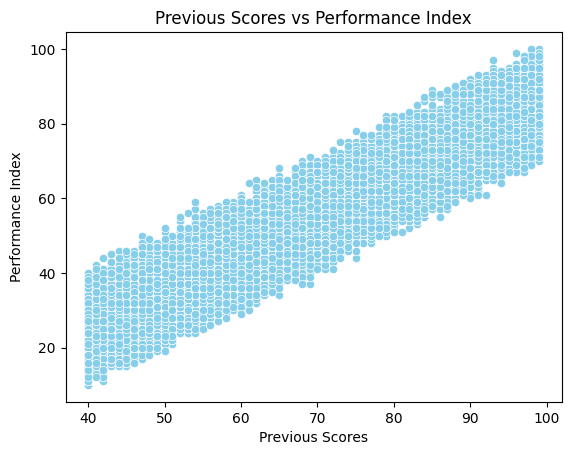

In [8]:
sns.scatterplot(x="Previous Scores", y="Performance Index", color="skyblue",data=df)
plt.title("Previous Scores vs Performance Index")
plt.show()

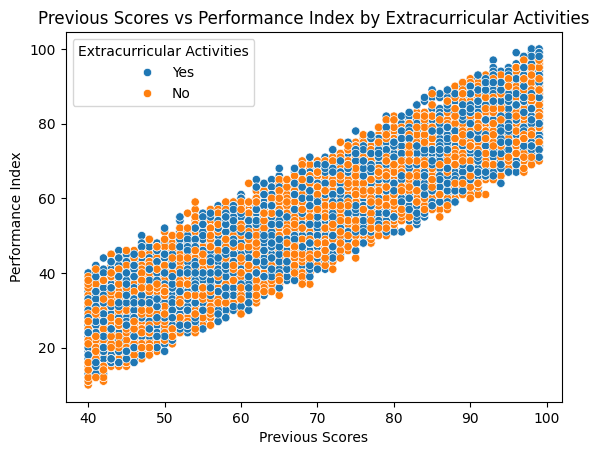

In [9]:
sns.scatterplot(x="Previous Scores", y="Performance Index", hue="Extracurricular Activities", color="orange,blue",data=df)
plt.title("Previous Scores vs Performance Index by Extracurricular Activities")
plt.show()

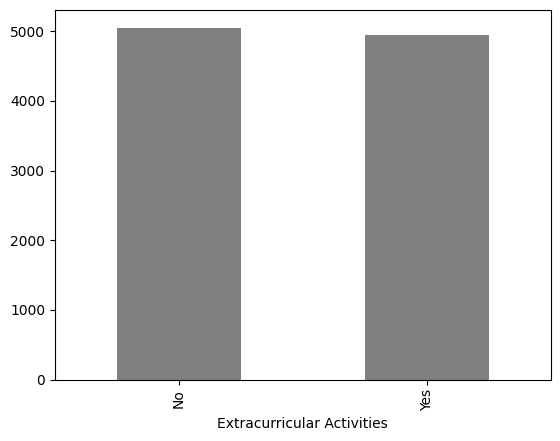

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64


In [10]:
df["Extracurricular Activities"].value_counts().plot(kind="bar", color="gray")
plt.show()
print(df["Extracurricular Activities"].value_counts())

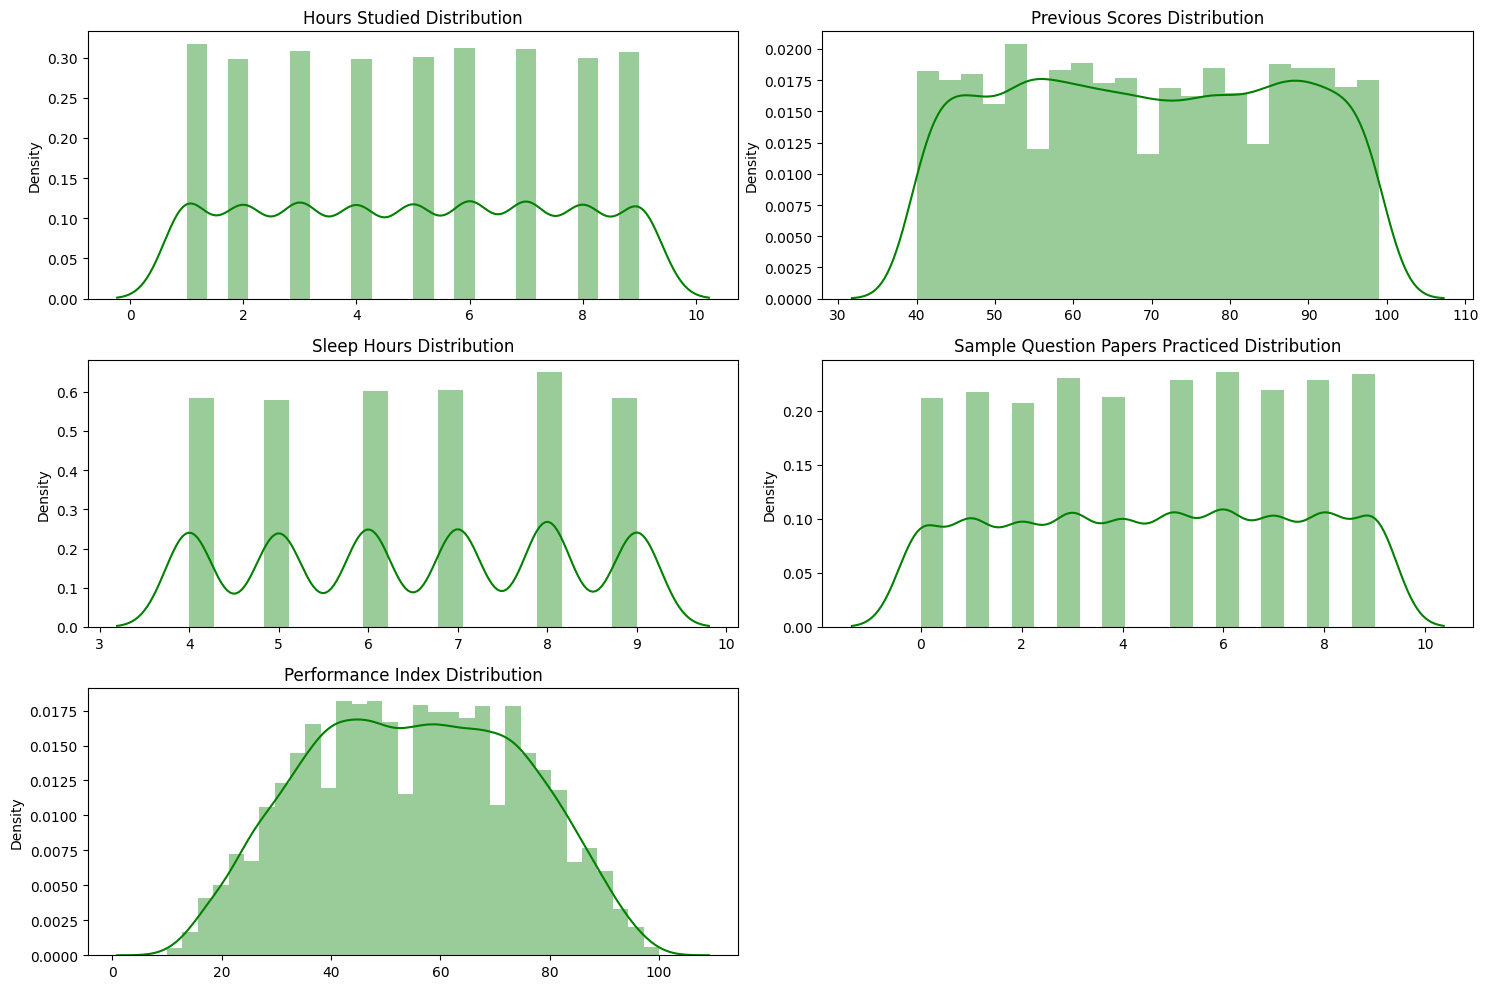

In [11]:
plt.figure(figsize=(15,10))
for i,col in enumerate(["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced", "Performance Index"]):
    plt.subplot(3,2,i+1)
    sns.distplot(df[col],color="green")
    plt.title(f"{col} Distribution")
    plt.xlabel("")
plt.tight_layout()
plt.show()

In [12]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


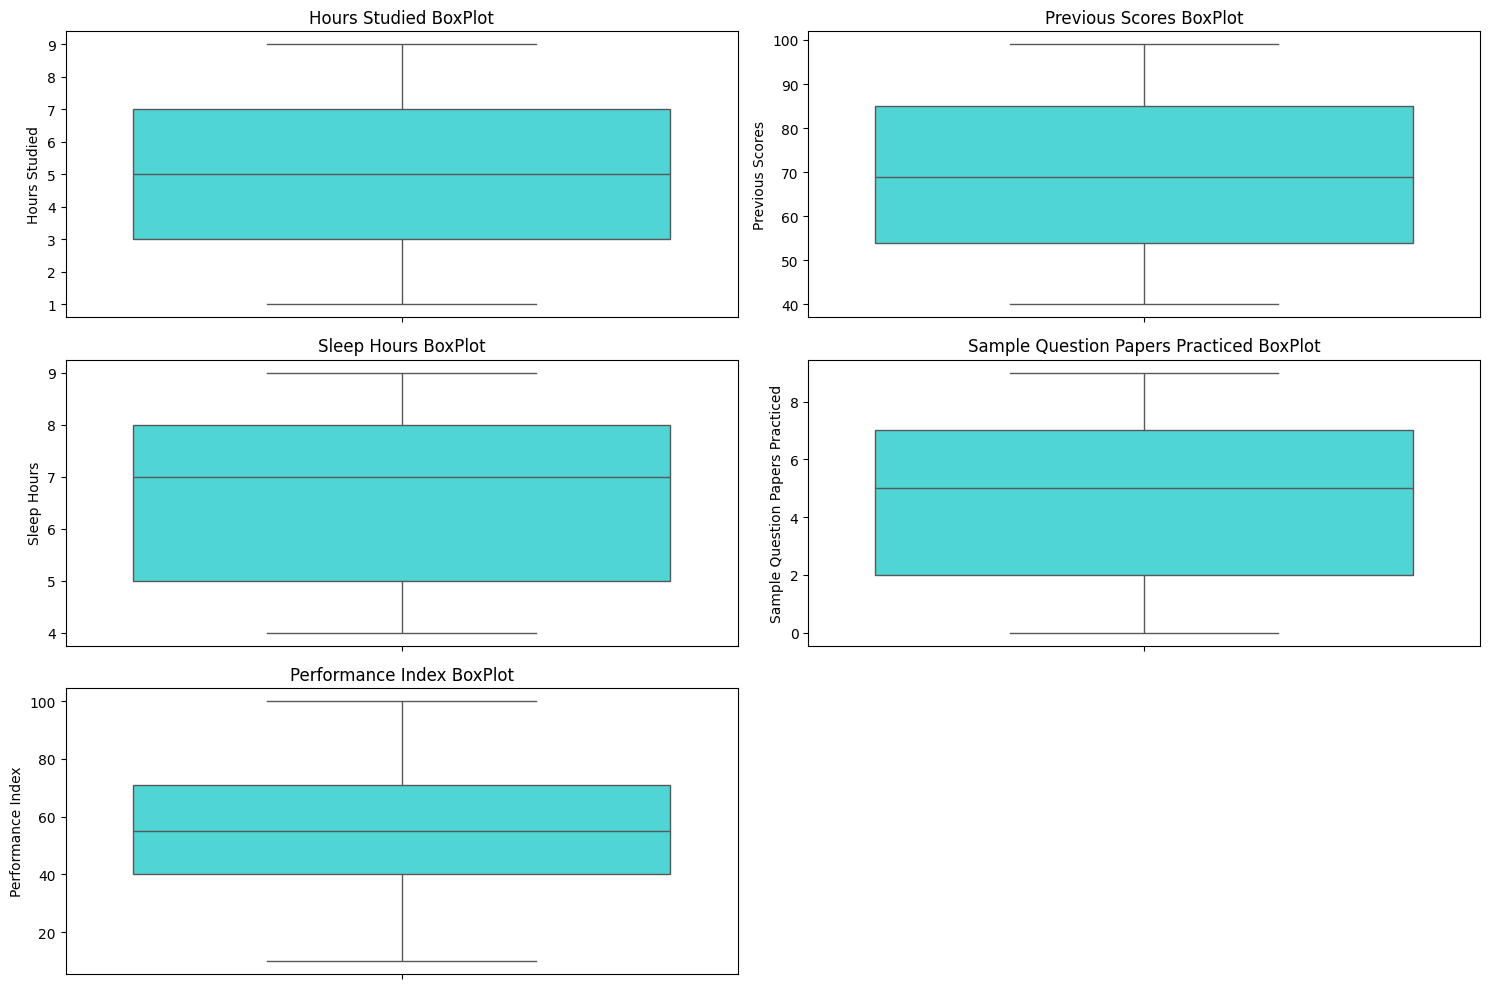

In [13]:
plt.figure(figsize=(15,10))
for i,col in enumerate(["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced", "Performance Index"]):
    plt.subplot(3,2,i+1)
    sns.boxplot(df[col],color="#39EBE9")
    plt.title(f"{col} BoxPlot")
    plt.xlabel("")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

x = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)
print((f"x train shape : {x_train.shape}"))
print(f"x test shape : {x_test.shape}")
print((f"y train shape : {y_train.shape}"))

x train shape : (7500, 5)
x test shape : (2500, 5)
y train shape : (7500,)


In [15]:
x_train["Extracurricular Activities"] = x_train["Extracurricular Activities"].map({"Yes":1,"No":0})
x_test["Extracurricular Activities"] = x_test["Extracurricular Activities"].map({"Yes":1,"No":0})
print(x_train["Extracurricular Activities"].unique())
print(x_test["Extracurricular Activities"].unique())

[0 1]
[0 1]


In [16]:
x_train.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
4901,5,49,0,5,5
4375,7,88,1,4,9
6698,3,94,1,7,1
9805,9,54,1,5,9
1101,4,56,1,8,6


In [17]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_score

In [20]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "ElasticNet" : ElasticNet(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random forest Regressor" : RandomForestRegressor()
}

In [21]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("------------------------------------")



LinearRegression()
RMSE : 2.008119571992444
Mean Absolute Error : 1.5975792091646108
R2 Score : <function r2_score at 0x0000022F5B1D7480>
------------------------------------
Lasso()
RMSE : 2.1954630374044095
Mean Absolute Error : 1.735894295901938
R2 Score : <function r2_score at 0x0000022F5B1D7480>
------------------------------------
Ridge()
RMSE : 2.0081238202509857
Mean Absolute Error : 1.5975800205432158
R2 Score : <function r2_score at 0x0000022F5B1D7480>
------------------------------------
ElasticNet()
RMSE : 2.1911455426928965
Mean Absolute Error : 1.7293004357445956
R2 Score : <function r2_score at 0x0000022F5B1D7480>
------------------------------------
KNeighborsRegressor()
RMSE : 2.4317006394702454
Mean Absolute Error : 1.9412
R2 Score : <function r2_score at 0x0000022F5B1D7480>
------------------------------------
DecisionTreeRegressor()
RMSE : 2.972638184807862
Mean Absolute Error : 2.3510666666666666
R2 Score : <function r2_score at 0x0000022F5B1D7480>
----------------